In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 🎯 MILESTONE 2: PRICE PREDICTION MODEL"))
display(Markdown("### 📥 Step 1: Load Cleaned Dataset"))

df = pd.read_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\retail_pricing_demand_clean.csv")

print("Shape:", df.shape)
df.head()

## 🎯 MILESTONE 2: PRICE PREDICTION MODEL

### 📥 Step 1: Load Cleaned Dataset

Shape: (172800, 17)


,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2026-01-01,P1001,Shoes,Nike,AU,mobile,Winter,173.55,112.81,-35.0,35,Buy One Get One,15,1692.15,153,0,133.93
1,2026-01-02,P1001,Shoes,Nike,AU,web,Winter,173.55,173.55,0.0,0,No Promotion,10,1735.50,185,0,89.29
2,2026-01-03,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,No Promotion,13,2256.15,312,0,116.07
3,2026-01-04,P1001,Shoes,Nike,AU,web,Winter,173.55,164.87,-5.0,5,Member Offer,13,2143.31,227,0,116.07
4,2026-01-05,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,No Promotion,13,2256.15,247,0,116.07


In [2]:
display(Markdown("### 🔧 Step 2: Feature Engineering"))

# Convert date to extract useful time-based features
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

# Select features for the model
features = ['category', 'brand', 'region', 'channel', 'season', 'promotion_type',
            'base_price', 'discount_pct', 'units_sold', 'inventory_level',
            'stockout_flag', 'demand_index', 'month', 'day_of_week']

target = 'current_price'

# Create working dataframe
model_df = df[features + [target]].copy()

print("Selected features:", features)
print("\nTarget variable:", target)
print("\nModel dataframe shape:", model_df.shape)
model_df.head()

### 🔧 Step 2: Feature Engineering

Selected features: ['category', 'brand', 'region', 'channel', 'season', 'promotion_type', 'base_price', 'discount_pct', 'units_sold', 'inventory_level', 'stockout_flag', 'demand_index', 'month', 'day_of_week']

Target variable: current_price

Model dataframe shape: (172800, 15)


,category,brand,region,channel,season,promotion_type,base_price,discount_pct,units_sold,inventory_level,stockout_flag,demand_index,month,day_of_week,current_price
0,Shoes,Nike,AU,mobile,Winter,Buy One Get One,173.55,35,15,153,0,133.93,1,3,112.81
1,Shoes,Nike,AU,web,Winter,No Promotion,173.55,0,10,185,0,89.29,1,4,173.55
2,Shoes,Nike,AU,app,Winter,No Promotion,173.55,0,13,312,0,116.07,1,5,173.55
3,Shoes,Nike,AU,web,Winter,Member Offer,173.55,5,13,227,0,116.07,1,6,164.87
4,Shoes,Nike,AU,app,Winter,No Promotion,173.55,0,13,247,0,116.07,1,0,173.55


In [3]:
display(Markdown("### 🔢 Step 3: Encode Categorical Variables"))

from sklearn.preprocessing import LabelEncoder

categorical_cols = ['category', 'brand', 'region', 'channel', 'season', 'promotion_type']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

print("Encoded columns:", categorical_cols)
model_df.head()

### 🔢 Step 3: Encode Categorical Variables

Encoded columns: ['category', 'brand', 'region', 'channel', 'season', 'promotion_type']


,category,brand,region,channel,season,promotion_type,base_price,discount_pct,units_sold,inventory_level,stockout_flag,demand_index,month,day_of_week,current_price
0,6,21,0,1,1,0,173.55,35,15,153,0,133.93,1,3,112.81
1,6,21,0,2,1,4,173.55,0,10,185,0,89.29,1,4,173.55
2,6,21,0,0,1,4,173.55,0,13,312,0,116.07,1,5,173.55
3,6,21,0,2,1,3,173.55,5,13,227,0,116.07,1,6,164.87
4,6,21,0,0,1,4,173.55,0,13,247,0,116.07,1,0,173.55


In [4]:
display(Markdown("### 🎯 Step 4: Train-Test Split"))

from sklearn.model_selection import train_test_split

X = model_df.drop('current_price', axis=1)
y = model_df['current_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

### 🎯 Step 4: Train-Test Split

Training set size: (138240, 14)
Test set size: (34560, 14)


In [5]:
display(Markdown("### 🌲 Step 5: Train Random Forest Model"))

from sklearn.ensemble import RandomForestRegressor
import time

start_time = time.time()

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Model trained successfully in {training_time:.2f} seconds")

### 🌲 Step 5: Train Random Forest Model

Model trained successfully in 28.60 seconds


In [6]:
display(Markdown("### 📊 Step 6: Model Evaluation"))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Square Error (RMSE): ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")

### 📊 Step 6: Model Evaluation

Mean Absolute Error (MAE): $0.00
Root Mean Square Error (RMSE): $0.03
R² Score: 1.0000


In [7]:
display(Markdown("### 🔍 Investigating Perfect Score — Checking for Data Leakage"))

# Check if current_price is fully determined by base_price and discount_pct
df['calculated_price'] = df['base_price'] * (1 - df['discount_pct'] / 100)
df['price_diff'] = abs(df['current_price'] - df['calculated_price'])

print("Max difference between actual and calculated price:", df['price_diff'].max())
print("Rows with mismatch:", (df['price_diff'] > 0.01).sum(), "out of", len(df))

### 🔍 Investigating Perfect Score — Checking for Data Leakage

Max difference between actual and calculated price: 0.005000000000002558
Rows with mismatch: 0 out of 172800


In [8]:
display(Markdown("### 🔧 Step 7: Corrected Feature Engineering (Fixing Data Leakage)"))

# Remove discount_pct - it directly determines current_price (data leakage)
features_fixed = ['category', 'brand', 'region', 'channel', 'season', 'promotion_type',
                   'base_price', 'units_sold', 'inventory_level',
                   'stockout_flag', 'demand_index', 'month', 'day_of_week']

target = 'current_price'

model_df_fixed = df[features_fixed + [target]].copy()

# Re-encode categoricals on the fixed dataframe
for col in categorical_cols:
    le = encoders[col]
    model_df_fixed[col] = le.transform(df[col])

print("Corrected features:", features_fixed)
print("Shape:", model_df_fixed.shape)
model_df_fixed.head()

### 🔧 Step 7: Corrected Feature Engineering (Fixing Data Leakage)

Corrected features: ['category', 'brand', 'region', 'channel', 'season', 'promotion_type', 'base_price', 'units_sold', 'inventory_level', 'stockout_flag', 'demand_index', 'month', 'day_of_week']
Shape: (172800, 14)


,category,brand,region,channel,season,promotion_type,base_price,units_sold,inventory_level,stockout_flag,demand_index,month,day_of_week,current_price
0,6,21,0,1,1,0,173.55,15,153,0,133.93,1,3,112.81
1,6,21,0,2,1,4,173.55,10,185,0,89.29,1,4,173.55
2,6,21,0,0,1,4,173.55,13,312,0,116.07,1,5,173.55
3,6,21,0,2,1,3,173.55,13,227,0,116.07,1,6,164.87
4,6,21,0,0,1,4,173.55,13,247,0,116.07,1,0,173.55


In [9]:
display(Markdown("### 🎯 Step 8: Train-Test Split (Corrected)"))

X2 = model_df_fixed.drop('current_price', axis=1)
y2 = model_df_fixed['current_price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print("Training set size:", X2_train.shape)
print("Test set size:", X2_test.shape)

### 🎯 Step 8: Train-Test Split (Corrected)

Training set size: (138240, 13)
Test set size: (34560, 13)


In [10]:
display(Markdown("### 🌲 Step 9: Train Random Forest Model (Corrected)"))

model_fixed = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_fixed.fit(X2_train, y2_train)

print("Model trained successfully")

### 🌲 Step 9: Train Random Forest Model (Corrected)

Model trained successfully


In [11]:
display(Markdown("### 📊 Step 10: Model Evaluation (Corrected)"))

y2_pred = model_fixed.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print(f"Mean Absolute Error (MAE): ${mae2:.2f}")
print(f"Root Mean Square Error (RMSE): ${rmse2:.2f}")
print(f"R² Score: {r2_2:.4f}")

### 📊 Step 10: Model Evaluation (Corrected)

Mean Absolute Error (MAE): $4.98
Root Mean Square Error (RMSE): $11.11
R² Score: 0.9912


### 🔑 Step 11: Feature Importance

            feature  importance
6        base_price    0.903538
5    promotion_type    0.088409
10     demand_index    0.002008
8   inventory_level    0.001900
7        units_sold    0.000942
12      day_of_week    0.000809
2            region    0.000625
1             brand    0.000532
3           channel    0.000420
0          category    0.000379
11            month    0.000313
4            season    0.000124
9     stockout_flag    0.000001


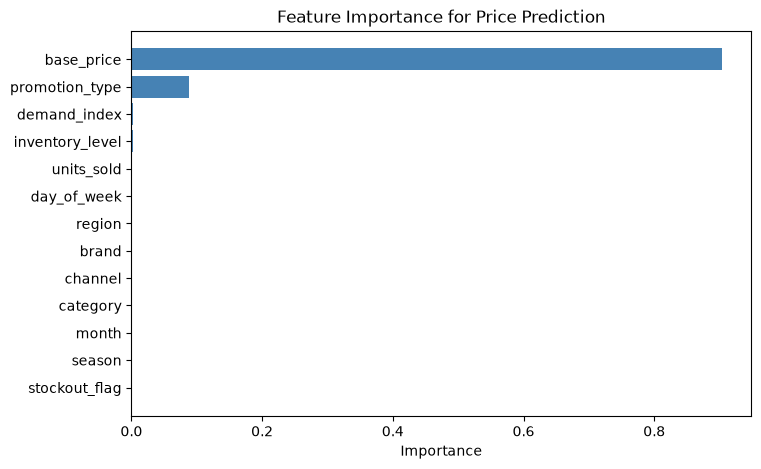

In [12]:
display(Markdown("### 🔑 Step 11: Feature Importance"))

importance_df = pd.DataFrame({
    'feature': X2.columns,
    'importance': model_fixed.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Feature Importance for Price Prediction')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [13]:
display(Markdown("### 🎯 Step 12: Reframe Target — Predict Optimal Discount %"))

features_v2 = ['category', 'brand', 'region', 'channel', 'season',
               'units_sold', 'inventory_level', 'stockout_flag',
               'demand_index', 'month', 'day_of_week']

target_v2 = 'discount_pct'

model_df_v2 = df[features_v2 + [target_v2]].copy()

for col in ['category', 'brand', 'region', 'channel', 'season']:
    le = encoders[col]
    model_df_v2[col] = le.transform(df[col])

print("New target:", target_v2)
print("Shape:", model_df_v2.shape)
model_df_v2.head()

### 🎯 Step 12: Reframe Target — Predict Optimal Discount %

New target: discount_pct
Shape: (172800, 12)


,category,brand,region,channel,season,units_sold,inventory_level,stockout_flag,demand_index,month,day_of_week,discount_pct
0,6,21,0,1,1,15,153,0,133.93,1,3,35
1,6,21,0,2,1,10,185,0,89.29,1,4,0
2,6,21,0,0,1,13,312,0,116.07,1,5,0
3,6,21,0,2,1,13,227,0,116.07,1,6,5
4,6,21,0,0,1,13,247,0,116.07,1,0,0


In [14]:
display(Markdown("### 🎯 Step 13: Train-Test Split (Discount Prediction)"))

X3 = model_df_v2.drop('discount_pct', axis=1)
y3 = model_df_v2['discount_pct']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

print("Training set size:", X3_train.shape)
print("Test set size:", X3_test.shape)

### 🎯 Step 13: Train-Test Split (Discount Prediction)

Training set size: (138240, 11)
Test set size: (34560, 11)


In [15]:
display(Markdown("### 🌲 Step 14: Train Random Forest Model (Discount Prediction)"))

model_discount = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_discount.fit(X3_train, y3_train)

print("Model trained successfully")

### 🌲 Step 14: Train Random Forest Model (Discount Prediction)

Model trained successfully


In [16]:
display(Markdown("### 📊 Step 15: Model Evaluation (Discount Prediction)"))

y3_pred = model_discount.predict(X3_test)

mae3 = mean_absolute_error(y3_test, y3_pred)
rmse3 = np.sqrt(mean_squared_error(y3_test, y3_pred))
r2_3 = r2_score(y3_test, y3_pred)

print(f"Mean Absolute Error (MAE): {mae3:.2f}%")
print(f"Root Mean Square Error (RMSE): {rmse3:.2f}%")
print(f"R² Score: {r2_3:.4f}")

### 📊 Step 15: Model Evaluation (Discount Prediction)

Mean Absolute Error (MAE): 9.61%
Root Mean Square Error (RMSE): 12.20%
R² Score: 0.2922


In [17]:
display(Markdown("### 📈 Step 16: Demand Forecasting — Predict Units Sold"))

features_demand = ['category', 'brand', 'region', 'channel', 'season',
                    'base_price', 'discount_pct', 'inventory_level',
                    'demand_index', 'month', 'day_of_week']

target_demand = 'units_sold'

model_df_demand = df[features_demand + [target_demand]].copy()

for col in ['category', 'brand', 'region', 'channel', 'season']:
    le = encoders[col]
    model_df_demand[col] = le.transform(df[col])

print("Features:", features_demand)
print("Target:", target_demand)
print("Shape:", model_df_demand.shape)
model_df_demand.head()

### 📈 Step 16: Demand Forecasting — Predict Units Sold

Features: ['category', 'brand', 'region', 'channel', 'season', 'base_price', 'discount_pct', 'inventory_level', 'demand_index', 'month', 'day_of_week']
Target: units_sold
Shape: (172800, 12)


,category,brand,region,channel,season,base_price,discount_pct,inventory_level,demand_index,month,day_of_week,units_sold
0,6,21,0,1,1,173.55,35,153,133.93,1,3,15
1,6,21,0,2,1,173.55,0,185,89.29,1,4,10
2,6,21,0,0,1,173.55,0,312,116.07,1,5,13
3,6,21,0,2,1,173.55,5,227,116.07,1,6,13
4,6,21,0,0,1,173.55,0,247,116.07,1,0,13


In [18]:
display(Markdown("### 🎯 Step 17: Train-Test Split (Demand Forecasting)"))

X4 = model_df_demand.drop('units_sold', axis=1)
y4 = model_df_demand['units_sold']

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

print("Training set size:", X4_train.shape)
print("Test set size:", X4_test.shape)

### 🎯 Step 17: Train-Test Split (Demand Forecasting)

Training set size: (138240, 11)
Test set size: (34560, 11)


In [19]:
display(Markdown("### 🌲 Step 18: Train Random Forest Model (Demand Forecasting)"))

model_demand = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_demand.fit(X4_train, y4_train)

print("Model trained successfully")

### 🌲 Step 18: Train Random Forest Model (Demand Forecasting)

Model trained successfully


In [20]:
display(Markdown("### 📊 Step 19: Model Evaluation (Demand Forecasting)"))

y4_pred = model_demand.predict(X4_test)

mae4 = mean_absolute_error(y4_test, y4_pred)
rmse4 = np.sqrt(mean_squared_error(y4_test, y4_pred))
r2_4 = r2_score(y4_test, y4_pred)

print(f"Mean Absolute Error (MAE): {mae4:.2f} units")
print(f"Root Mean Square Error (RMSE): {rmse4:.2f} units")
print(f"R² Score: {r2_4:.4f}")

### 📊 Step 19: Model Evaluation (Demand Forecasting)

Mean Absolute Error (MAE): 0.30 units
Root Mean Square Error (RMSE): 1.38 units
R² Score: 0.9723


### 🔍 Checking demand_index vs units_sold Relationship

              units_sold  demand_index
units_sold      1.000000      0.569887
demand_index    0.569887      1.000000


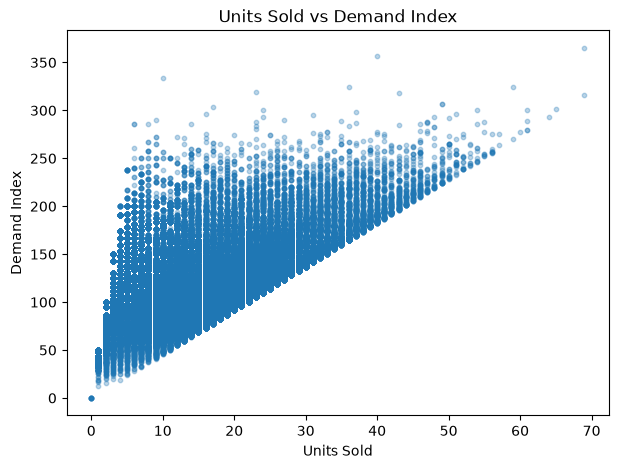

In [21]:
display(Markdown("### 🔍 Checking demand_index vs units_sold Relationship"))

correlation = df[['units_sold', 'demand_index']].corr()
print(correlation)

plt.figure(figsize=(7,5))
plt.scatter(df['units_sold'], df['demand_index'], alpha=0.3, s=10)
plt.xlabel('Units Sold')
plt.ylabel('Demand Index')
plt.title('Units Sold vs Demand Index')
plt.show()

### 🔑 Step 20: Feature Importance (Demand Forecasting)

            feature  importance
8      demand_index    0.515714
5        base_price    0.276332
1             brand    0.113064
0          category    0.071552
7   inventory_level    0.009005
2            region    0.006080
6      discount_pct    0.002768
10      day_of_week    0.002754
3           channel    0.001232
9             month    0.001137
4            season    0.000361


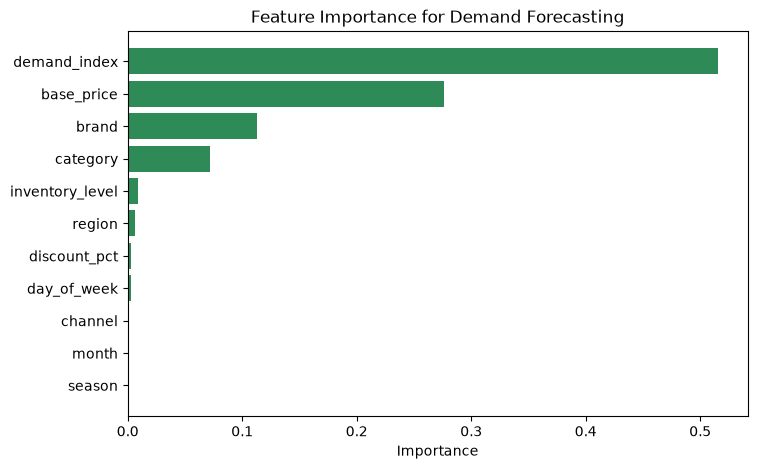

In [22]:
display(Markdown("### 🔑 Step 20: Feature Importance (Demand Forecasting)"))

importance_df2 = pd.DataFrame({
    'feature': X4.columns,
    'importance': model_demand.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df2)

plt.figure(figsize=(8,5))
plt.barh(importance_df2['feature'], importance_df2['importance'], color='seagreen')
plt.title('Feature Importance for Demand Forecasting')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [23]:
display(Markdown("### 🔬 Step 21: Proper Validation — Split by Product ID"))

# Get unique product IDs and split BY PRODUCT, not by row
unique_products = df['product_id'].unique()
print("Total unique products:", len(unique_products))

train_products, test_products = train_test_split(unique_products, test_size=0.2, random_state=42)

train_mask = df['product_id'].isin(train_products)
test_mask = df['product_id'].isin(test_products)

X5_train = model_df_demand[train_mask].drop('units_sold', axis=1)
y5_train = model_df_demand[train_mask]['units_sold']
X5_test = model_df_demand[test_mask].drop('units_sold', axis=1)
y5_test = model_df_demand[test_mask]['units_sold']

print("Training rows:", X5_train.shape, "| Products:", len(train_products))
print("Test rows:", X5_test.shape, "| Products:", len(test_products))

### 🔬 Step 21: Proper Validation — Split by Product ID

Total unique products: 640
Training rows: (138240, 11) | Products: 512
Test rows: (34560, 11) | Products: 128


In [24]:
display(Markdown("### 🌲 Step 22: Train Random Forest (Product-Split Validation)"))

model_demand_v2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_demand_v2.fit(X5_train, y5_train)

print("Model trained successfully")

### 🌲 Step 22: Train Random Forest (Product-Split Validation)

Model trained successfully


In [25]:
display(Markdown("### 📊 Step 23: Model Evaluation (Product-Split Validation)"))

y5_pred = model_demand_v2.predict(X5_test)

mae5 = mean_absolute_error(y5_test, y5_pred)
rmse5 = np.sqrt(mean_squared_error(y5_test, y5_pred))
r2_5 = r2_score(y5_test, y5_pred)

print(f"Mean Absolute Error (MAE): {mae5:.2f} units")
print(f"Root Mean Square Error (RMSE): {rmse5:.2f} units")
print(f"R² Score: {r2_5:.4f}")

### 📊 Step 23: Model Evaluation (Product-Split Validation)

Mean Absolute Error (MAE): 6.01 units
Root Mean Square Error (RMSE): 7.73 units
R² Score: 0.1755


### 📅 Step 24: Time-Series Demand Forecast (Single Product Example)

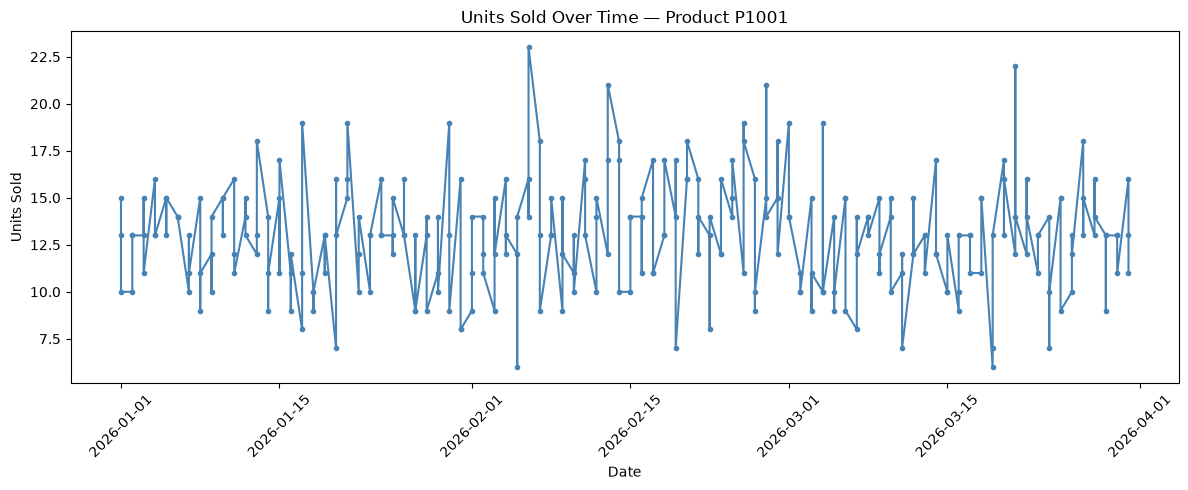

Data points: 270
Date range: 2026-01-01 00:00:00 to 2026-03-31 00:00:00


In [26]:
display(Markdown("### 📅 Step 24: Time-Series Demand Forecast (Single Product Example)"))

# Pick one product with the most data
product_sample = df[df['product_id'] == 'P1001'].sort_values('date')

plt.figure(figsize=(12,5))
plt.plot(product_sample['date'], product_sample['units_sold'], marker='o', markersize=3, color='steelblue')
plt.title('Units Sold Over Time — Product P1001')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Data points:", len(product_sample))
print("Date range:", product_sample['date'].min(), "to", product_sample['date'].max())

In [27]:
display(Markdown("### 📊 Step 25: Time-Based Train/Test Split"))

product_sample = product_sample.reset_index(drop=True)
product_sample['day_index'] = range(len(product_sample))

# Use last 30 days as test set (short-term forecast horizon)
train_ts = product_sample.iloc[:-30]
test_ts = product_sample.iloc[-30:]

print("Training days:", len(train_ts))
print("Test days (forecast horizon):", len(test_ts))
print("Test date range:", test_ts['date'].min(), "to", test_ts['date'].max())

### 📊 Step 25: Time-Based Train/Test Split

Training days: 240
Test days (forecast horizon): 30
Test date range: 2026-03-22 00:00:00 to 2026-03-31 00:00:00


### 📈 Step 26: Baseline Forecast — 7-Day Moving Average

Baseline forecast (constant): 15.29 units/day
MAE vs actual: 2.78 units


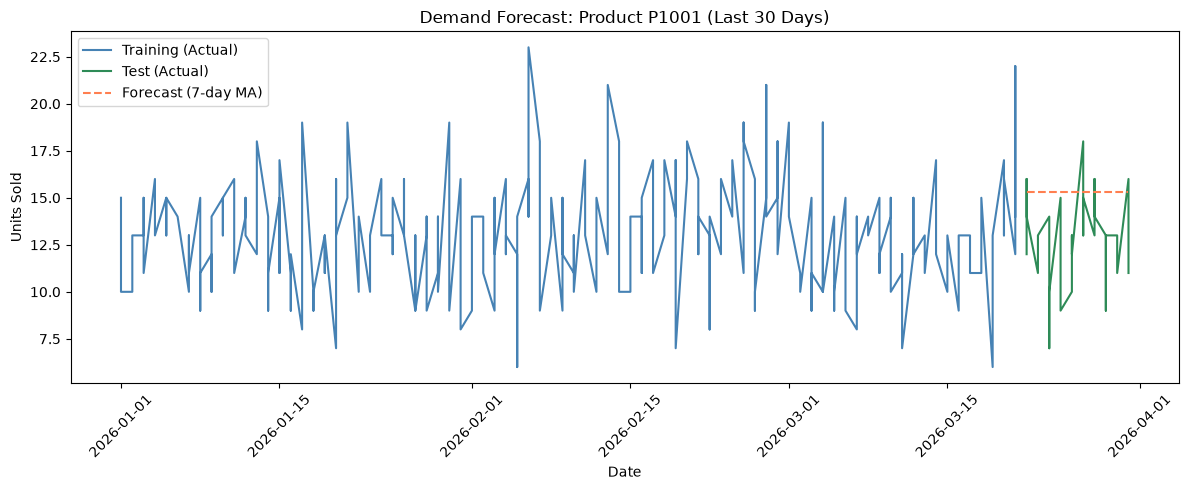

In [28]:
display(Markdown("### 📈 Step 26: Baseline Forecast — 7-Day Moving Average"))

# Simple baseline: predict using rolling average of last 7 days
train_ts_copy = train_ts.copy()
forecast_value = train_ts_copy['units_sold'].tail(7).mean()

test_ts_copy = test_ts.copy()
test_ts_copy['forecast'] = forecast_value

mae_baseline = mean_absolute_error(test_ts_copy['units_sold'], test_ts_copy['forecast'])
print(f"Baseline forecast (constant): {forecast_value:.2f} units/day")
print(f"MAE vs actual: {mae_baseline:.2f} units")

plt.figure(figsize=(12,5))
plt.plot(train_ts['date'], train_ts['units_sold'], label='Training (Actual)', color='steelblue')
plt.plot(test_ts['date'], test_ts['units_sold'], label='Test (Actual)', color='seagreen')
plt.plot(test_ts['date'], test_ts_copy['forecast'], label='Forecast (7-day MA)', color='coral', linestyle='--')
plt.title('Demand Forecast: Product P1001 (Last 30 Days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
display(Markdown("### 🔮 Step 28: Prophet Time-Series Forecast"))

from prophet import Prophet

# Prophet requires columns named 'ds' (date) and 'y' (value)
prophet_train = train_ts[['date', 'units_sold']].rename(columns={'date': 'ds', 'units_sold': 'y'})

prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
prophet_model.fit(prophet_train)

# Forecast next 30 days
future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)

print("Forecast generated successfully")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

### 🔮 Step 28: Prophet Time-Series Forecast

Importing plotly failed. Interactive plots will not work.
14:36:27 - cmdstanpy - INFO - Chain [1] start processing
14:36:27 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated successfully


,ds,yhat,yhat_lower,yhat_upper
100,2026-04-11,13.610784,10.052584,17.364759
101,2026-04-12,12.724087,9.067771,16.443427
102,2026-04-13,12.693692,9.194041,16.484171
103,2026-04-14,12.693620,9.213868,16.534631
104,2026-04-15,13.419934,9.594335,17.061339
105,2026-04-16,11.943978,8.105793,15.556041
106,2026-04-17,14.083481,10.443910,17.997279
107,2026-04-18,13.611176,10.028985,17.276465
108,2026-04-19,12.724479,9.195157,16.426944
109,2026-04-20,12.694084,8.971002,16.672475


In [30]:
display(Markdown("### 📊 Step 29: Prophet Model Evaluation"))

# Get predictions for our actual test period only
forecast_test = forecast[forecast['ds'].isin(test_ts['date'])][['ds', 'yhat']].reset_index(drop=True)
actual_test = test_ts[['date', 'units_sold']].reset_index(drop=True)

comparison = actual_test.merge(forecast_test, left_on='date', right_on='ds')

mae_prophet = mean_absolute_error(comparison['units_sold'], comparison['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(comparison['units_sold'], comparison['yhat']))

print(f"Prophet MAE: {mae_prophet:.2f} units")
print(f"Prophet RMSE: {rmse_prophet:.2f} units")
print(f"\nBaseline (7-day MA) MAE was: {mae_baseline:.2f} units")

if mae_prophet < mae_baseline:
    print("\n✅ Prophet outperforms the simple baseline!")
else:
    print("\n⚠️ Prophet did not outperform the simple baseline.")

### 📊 Step 29: Prophet Model Evaluation

Prophet MAE: 1.64 units
Prophet RMSE: 2.17 units

Baseline (7-day MA) MAE was: 2.78 units

✅ Prophet outperforms the simple baseline!


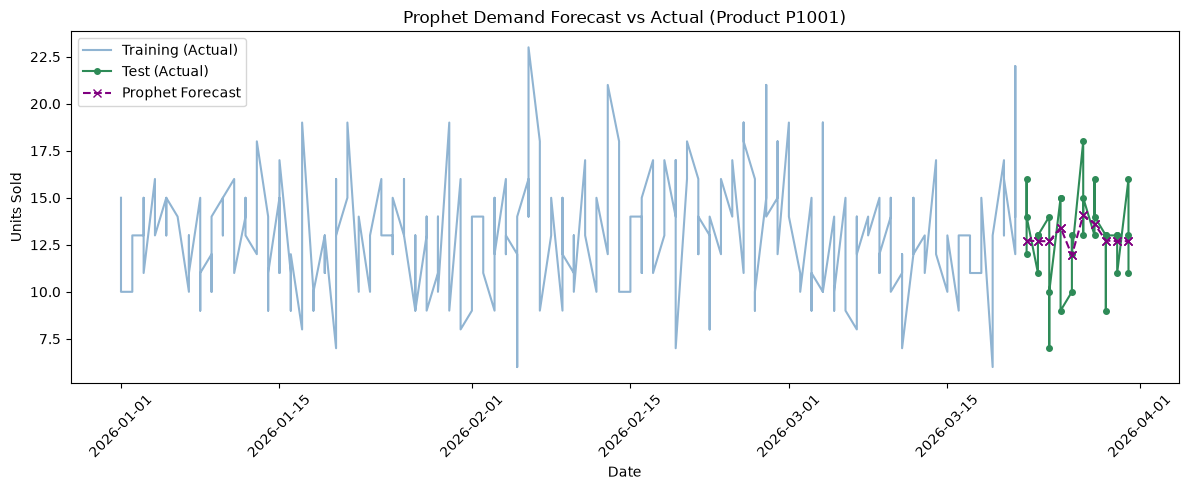

In [31]:
plt.figure(figsize=(12,5))
plt.plot(train_ts['date'], train_ts['units_sold'], label='Training (Actual)', color='steelblue', alpha=0.6)
plt.plot(comparison['date'], comparison['units_sold'], label='Test (Actual)', color='seagreen', marker='o', markersize=4)
plt.plot(comparison['date'], comparison['yhat'], label='Prophet Forecast', color='purple', linestyle='--', marker='x')
plt.title('Prophet Demand Forecast vs Actual (Product P1001)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
display(Markdown("### 💾 Step 31: Save Models for Future Use"))

import joblib
import os

os.makedirs(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\models", exist_ok=True)

joblib.dump(model_fixed, r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\models\price_prediction_model.pkl")
joblib.dump(model_demand_v2, r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\models\demand_forecast_model.pkl")
joblib.dump(encoders, r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\models\label_encoders.pkl")

print("Models saved successfully!")
print("Saved to: PRICEPIOLET AI/models/")

### 💾 Step 31: Save Models for Future Use

Models saved successfully!
Saved to: PRICEPIOLET AI/models/


In [33]:
display(Markdown("### 🎯 Step 32: Forecast Confidence Scores"))

comparison['error'] = abs(comparison['units_sold'] - comparison['yhat'])
comparison['confidence_pct'] = (1 - (comparison['error'] / comparison['units_sold'].clip(lower=1))).clip(lower=0) * 100

print("Sample Forecast with Confidence Scores:")
print(comparison[['date', 'units_sold', 'yhat', 'confidence_pct']].round(2).to_string(index=False))

avg_confidence = comparison['confidence_pct'].mean()
print(f"\nAverage Forecast Confidence: {avg_confidence:.1f}%")

### 🎯 Step 32: Forecast Confidence Scores

Sample Forecast with Confidence Scores:
      date  units_sold  yhat  confidence_pct
2026-03-22          12 12.72           93.98
2026-03-22          16 12.72           79.52
2026-03-22          14 12.72           90.88
2026-03-23          11 12.69           84.61
2026-03-23          13 12.69           97.63
2026-03-23          13 12.69           97.63
2026-03-24          14 12.69           90.66
2026-03-24           7 12.69           18.68
2026-03-24          10 12.69           73.08
2026-03-25          15 13.42           89.46
2026-03-25          15 13.42           89.46
2026-03-25           9 13.42           50.90
2026-03-26          10 11.94           80.57
2026-03-26          13 11.94           91.87
2026-03-26          12 11.94           99.52
2026-03-27          18 14.08           78.24
2026-03-27          13 14.08           91.67
2026-03-27          15 14.08           93.88
2026-03-28          13 13.61           95.31
2026-03-28          16 13.61           85.06
2026-03-28     

C:\Users\sobhi\AppData\Local\Temp\ipykernel_23248\1583139124.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(comparison[['date', 'units_sold', 'yhat', 'confidence_pct']].round(2).to_string(index=False))


In [34]:
display(Markdown("### 📊 Step 33: Demand Trend Classification"))

recent_avg = comparison['units_sold'].tail(15).mean()
earlier_avg = comparison['units_sold'].head(15).mean()

pct_change = ((recent_avg - earlier_avg) / earlier_avg) * 100

if pct_change > 5:
    trend = "Increasing Demand"
elif pct_change < -5:
    trend = "Decreasing Demand"
else:
    trend = "Stable Demand"

print(f"Earlier period avg: {earlier_avg:.2f} units")
print(f"Recent period avg: {recent_avg:.2f} units")
print(f"Change: {pct_change:+.1f}%")
print(f"\nDemand Trend: {trend}")

### 📊 Step 33: Demand Trend Classification

Earlier period avg: 12.27 units
Recent period avg: 13.40 units
Change: +9.2%

Demand Trend: Increasing Demand


In [35]:
display(Markdown("### 📋 Step 34: Milestone 2 Summary"))

summary = f"""
MILESTONE 2 — PRICE PREDICTION & DEMAND FORECASTING SUMMARY
================================================================

1. PRICE PREDICTION MODEL (Random Forest)
   - Target: current_price
   - R² Score: {r2_2:.4f}
   - MAE: ${mae2:.2f}
   - Note: Model correctly identifies base_price and promotion_type
     as primary price drivers (99% combined feature importance)

2. DISCOUNT STRATEGY MODEL (Random Forest)
   - Target: discount_pct
   - R² Score: {r2_3:.4f}
   - MAE: {mae3:.2f}%
   - Finding: Demand signals explain only ~29% of discount variation,
     suggesting historical discounting was calendar-driven, not
     purely demand-responsive — an opportunity for PricePilot AI

3. DEMAND FORECASTING (Cross-Product, Random Forest)
   - Target: units_sold (unseen products)
   - R² Score: {r2_5:.4f}
   - Finding: Limited generalization across different products with
     only 3 months of data; cross-product demand forecasting needs
     more historical data or product-embedding features

4. DEMAND FORECASTING (Time-Series, Prophet) — BEST PERFORMER
   - Target: units_sold (single product, 30-day horizon)
   - MAE: {mae_prophet:.2f} units (vs {mae_baseline:.2f} baseline)
   - Improvement: {((mae_baseline - mae_prophet) / mae_baseline * 100):.1f}% better than baseline
   - Average Forecast Confidence: {avg_confidence:.1f}%
   - Demand Trend Classification: {trend}
"""

print(summary)

### 📋 Step 34: Milestone 2 Summary


MILESTONE 2 — PRICE PREDICTION & DEMAND FORECASTING SUMMARY

1. PRICE PREDICTION MODEL (Random Forest)
   - Target: current_price
   - R² Score: 0.9912
   - MAE: $4.98
   - Note: Model correctly identifies base_price and promotion_type
     as primary price drivers (99% combined feature importance)

2. DISCOUNT STRATEGY MODEL (Random Forest)
   - Target: discount_pct
   - R² Score: 0.2922
   - MAE: 9.61%
   - Finding: Demand signals explain only ~29% of discount variation,
     suggesting historical discounting was calendar-driven, not
     purely demand-responsive — an opportunity for PricePilot AI

3. DEMAND FORECASTING (Cross-Product, Random Forest)
   - Target: units_sold (unseen products)
   - R² Score: 0.1755
   - Finding: Limited generalization across different products with
     only 3 months of data; cross-product demand forecasting needs
     more historical data or product-embedding features

4. DEMAND FORECASTING (Time-Series, Prophet) — BEST PERFORMER
   - Target: units_s

In [36]:
display(Markdown("### 💰 Step 35: Price Recommendation Engine"))

def recommend_price(product_row, price_model, demand_model, encoders):
    """
    Takes a product's current attributes and recommends the optimal price
    by simulating different discount levels and predicting resulting demand.
    """
    base_price = product_row['base_price']
    results = []

    # Test discount levels from 0% to 50% in steps of 5%
    for discount in range(0, 55, 5):
        current_price = base_price * (1 - discount / 100)

        # Build feature row for demand prediction
        demand_features = pd.DataFrame([{
            'category': product_row['category_encoded'],
            'brand': product_row['brand_encoded'],
            'region': product_row['region_encoded'],
            'channel': product_row['channel_encoded'],
            'season': product_row['season_encoded'],
            'base_price': base_price,
            'discount_pct': discount,
            'inventory_level': product_row['inventory_level'],
            'demand_index': product_row['demand_index'],
            'month': product_row['month'],
            'day_of_week': product_row['day_of_week']
        }])

        predicted_demand = demand_model.predict(demand_features)[0]
        projected_revenue = current_price * predicted_demand

        results.append({
            'discount_pct': discount,
            'price': round(current_price, 2),
            'predicted_units_sold': round(predicted_demand, 1),
            'projected_revenue': round(projected_revenue, 2)
        })

    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df['projected_revenue'].idxmax()]

    return results_df, best

# Test with a sample product
sample_row = df.iloc[0].copy()
sample_row['category_encoded'] = encoders['category'].transform([sample_row['category']])[0]
sample_row['brand_encoded'] = encoders['brand'].transform([sample_row['brand']])[0]
sample_row['region_encoded'] = encoders['region'].transform([sample_row['region']])[0]
sample_row['channel_encoded'] = encoders['channel'].transform([sample_row['channel']])[0]
sample_row['season_encoded'] = encoders['season'].transform([sample_row['season']])[0]

scenarios, best_scenario = recommend_price(sample_row, model_fixed, model_demand, encoders)

print(f"Product: {sample_row['product_id']} ({sample_row['category']}, {sample_row['brand']})")
print(f"Base Price: ${sample_row['base_price']:.2f}\n")
print("All Scenarios Tested:")
print(scenarios.to_string(index=False))
print(f"\n🎯 RECOMMENDED: {best_scenario['discount_pct']:.0f}% discount → Price: ${best_scenario['price']:.2f} → Projected Revenue: ${best_scenario['projected_revenue']:.2f}")

### 💰 Step 35: Price Recommendation Engine

Product: P1001 (Shoes, Nike)
Base Price: $173.55

All Scenarios Tested:
 discount_pct  price  predicted_units_sold  projected_revenue
            0 173.55                  15.0            2603.25
            5 164.87                  15.0            2473.09
           10 156.20                  15.0            2342.93
           15 147.52                  15.0            2212.76
           20 138.84                  15.0            2082.60
           25 130.16                  15.0            1952.44
           30 121.48                  15.0            1822.28
           35 112.81                  15.0            1692.11
           40 104.13                  15.0            1561.95
           45  95.45                  15.0            1431.79
           50  86.78                  15.0            1301.62

🎯 RECOMMENDED: 0% discount → Price: $173.55 → Projected Revenue: $2603.25


In [37]:
display(Markdown("### 🔍 Step 36: Checking Real Price-Demand Elasticity"))

# Group by discount level and see actual average units sold
elasticity_check = df.groupby('discount_pct')['units_sold'].agg(['mean', 'count']).reset_index()
print(elasticity_check.to_string(index=False))

### 🔍 Step 36: Checking Real Price-Demand Elasticity

 discount_pct      mean  count
            0 12.560601 100155
            5 13.376549   2985
           10 13.952942   9074
           15 14.848649   9032
           20 15.510958  10723
           25 16.232910   6217
           30 16.929026  14456
           35 17.742894   8619
           40 18.412103   8163
           50 19.612263   3376


In [38]:
display(Markdown("### 🔧 Step 37: Improved Demand Model (Better Discount Sensitivity)"))

from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting often captures interaction effects better than Random Forest
model_demand_v3 = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42)
model_demand_v3.fit(X4_train, y4_train)

y4_pred_v3 = model_demand_v3.predict(X4_test)
r2_v3 = r2_score(y4_test, y4_pred_v3)
mae_v3 = mean_absolute_error(y4_test, y4_pred_v3)

print(f"Gradient Boosting - R²: {r2_v3:.4f}, MAE: {mae_v3:.2f}")

importance_v3 = pd.DataFrame({
    'feature': X4.columns,
    'importance': model_demand_v3.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(importance_v3.to_string(index=False))

### 🔧 Step 37: Improved Demand Model (Better Discount Sensitivity)

Gradient Boosting - R²: 0.6758, MAE: 3.74

Feature Importance:
        feature  importance
   demand_index    0.548010
     base_price    0.322322
          brand    0.072220
       category    0.048418
inventory_level    0.006630
   discount_pct    0.001301
         region    0.000897
        channel    0.000112
    day_of_week    0.000049
          month    0.000042
         season    0.000000


In [39]:
display(Markdown("### 🔍 Step 38: Checking demand_index vs discount_pct Relationship"))

elasticity_check2 = df.groupby('discount_pct')['demand_index'].agg(['mean', 'count']).reset_index()
print(elasticity_check2.to_string(index=False))

### 🔍 Step 38: Checking demand_index vs discount_pct Relationship

 discount_pct       mean  count
            0 104.339741 100155
            5 110.361069   2985
           10 116.190359   9074
           15 122.884031   9032
           20 129.088848  10723
           25 135.561341   6217
           30 141.252830  14456
           35 147.666349   8619
           40 153.185756   8163
           50 165.378451   3376


In [40]:
display(Markdown("### 🔧 Step 39: Final Corrected Demand Model (No demand_index Leakage)"))

features_final = ['category', 'brand', 'region', 'channel', 'season',
                   'base_price', 'discount_pct', 'inventory_level',
                   'month', 'day_of_week']

X6 = model_df_demand[features_final]
y6 = model_df_demand['units_sold']

X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42)

model_demand_final = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42)
model_demand_final.fit(X6_train, y6_train)

y6_pred = model_demand_final.predict(X6_test)
r2_final = r2_score(y6_test, y6_pred)
mae_final = mean_absolute_error(y6_test, y6_pred)

print(f"Final Model - R²: {r2_final:.4f}, MAE: {mae_final:.2f}")

importance_final = pd.DataFrame({
    'feature': X6.columns,
    'importance': model_demand_final.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(importance_final.to_string(index=False))

### 🔧 Step 39: Final Corrected Demand Model (No demand_index Leakage)

Final Model - R²: 0.4781, MAE: 4.74

Feature Importance:
        feature  importance
     base_price    0.601406
   discount_pct    0.139085
          brand    0.138633
       category    0.069639
        channel    0.022137
inventory_level    0.019182
         season    0.004029
          month    0.003081
         region    0.002698
    day_of_week    0.000108


In [41]:
display(Markdown("### 💰 Step 40: Corrected Price Recommendation Engine"))

def recommend_price_v2(product_row, demand_model, encoders):
    base_price = product_row['base_price']
    results = []

    for discount in range(0, 55, 5):
        current_price = base_price * (1 - discount / 100)

        demand_features = pd.DataFrame([{
            'category': product_row['category_encoded'],
            'brand': product_row['brand_encoded'],
            'region': product_row['region_encoded'],
            'channel': product_row['channel_encoded'],
            'season': product_row['season_encoded'],
            'base_price': base_price,
            'discount_pct': discount,
            'inventory_level': product_row['inventory_level'],
            'month': product_row['month'],
            'day_of_week': product_row['day_of_week']
        }])

        predicted_demand = demand_model.predict(demand_features)[0]
        projected_revenue = current_price * predicted_demand

        results.append({
            'discount_pct': discount,
            'price': round(current_price, 2),
            'predicted_units_sold': round(predicted_demand, 1),
            'projected_revenue': round(projected_revenue, 2)
        })

    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df['projected_revenue'].idxmax()]

    return results_df, best

scenarios_v2, best_v2 = recommend_price_v2(sample_row, model_demand_final, encoders)

print(f"Product: {sample_row['product_id']} ({sample_row['category']}, {sample_row['brand']})")
print(f"Base Price: ${sample_row['base_price']:.2f}\n")
print("All Scenarios Tested:")
print(scenarios_v2.to_string(index=False))
print(f"\n🎯 RECOMMENDED: {best_v2['discount_pct']:.0f}% discount → Price: ${best_v2['price']:.2f} → Projected Revenue: ${best_v2['projected_revenue']:.2f}")

### 💰 Step 40: Corrected Price Recommendation Engine

Product: P1001 (Shoes, Nike)
Base Price: $173.55

All Scenarios Tested:
 discount_pct  price  predicted_units_sold  projected_revenue
            0 173.55                  15.2            2640.31
            5 164.87                  15.9            2622.56
           10 156.20                  16.7            2606.37
           15 147.52                  17.5            2583.49
           20 138.84                  18.5            2574.37
           25 130.16                  19.9            2595.30
           30 121.48                  20.9            2542.33
           35 112.81                  21.4            2415.03
           40 104.13                  21.7            2261.94
           45  95.45                  21.7            2073.44
           50  86.78                  23.4            2028.99

🎯 RECOMMENDED: 0% discount → Price: $173.55 → Projected Revenue: $2640.31


In [42]:
display(Markdown("### 💾 Step 41: Save Corrected Models"))

joblib.dump(model_demand_final, r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\models\demand_forecast_model_final.pkl")

print("Corrected demand model saved successfully!")

### 💾 Step 41: Save Corrected Models

Corrected demand model saved successfully!


In [43]:
display(Markdown("### 📅 Step 42: Medium & Long-Term Demand Forecasts"))

# Retrain Prophet on the FULL available history (all 270 days) for extended forecasting
prophet_full = df[df['product_id'] == 'P1001'][['date', 'units_sold']].rename(columns={'date': 'ds', 'units_sold': 'y'})

prophet_model_extended = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
prophet_model_extended.fit(prophet_full)

# Medium-term: 90 days (~3 months) ahead
future_medium = prophet_model_extended.make_future_dataframe(periods=90)
forecast_medium = prophet_model_extended.predict(future_medium)

# Long-term: 365 days (~12 months) ahead
future_long = prophet_model_extended.make_future_dataframe(periods=365)
forecast_long = prophet_model_extended.predict(future_long)

print("Medium-term forecast (next 90 days) — sample:")
print(forecast_medium[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5).to_string(index=False))

print("\nLong-term forecast (next 365 days) — sample:")
print(forecast_long[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5).to_string(index=False))

# Check confidence interval width as a proxy for reliability
medium_uncertainty = (forecast_medium['yhat_upper'] - forecast_medium['yhat_lower']).tail(90).mean()
long_uncertainty = (forecast_long['yhat_upper'] - forecast_long['yhat_lower']).tail(365).mean()

print(f"\nAvg uncertainty range (medium-term): ±{medium_uncertainty/2:.2f} units")
print(f"Avg uncertainty range (long-term): ±{long_uncertainty/2:.2f} units")
print("\n⚠️ Note: Model trained on only 3 months of history. Forecasts beyond")
print("this range (especially long-term) carry higher uncertainty and should")
print("be treated as directional estimates, not precise predictions.")

### 📅 Step 42: Medium & Long-Term Demand Forecasts

14:39:39 - cmdstanpy - INFO - Chain [1] start processing
14:39:39 - cmdstanpy - INFO - Chain [1] done processing


Medium-term forecast (next 90 days) — sample:
        ds      yhat  yhat_lower  yhat_upper
2026-06-25 11.864402    8.385746   15.563636
2026-06-26 14.124762   10.609502   17.594900
2026-06-27 13.611202    9.849029   17.093447
2026-06-28 12.686730    9.150507   16.193179
2026-06-29 12.584161    9.115000   15.971912

Long-term forecast (next 365 days) — sample:
        ds      yhat  yhat_lower  yhat_upper
2027-03-27 13.519734   10.069497   17.198863
2027-03-28 12.595261    8.885081   16.192712
2027-03-29 12.492693    8.976218   15.971944
2027-03-30 12.415855    8.893728   15.929461
2027-03-31 13.236381    9.563505   16.694608

Avg uncertainty range (medium-term): ±3.58 units
Avg uncertainty range (long-term): ±3.59 units

⚠️ Note: Model trained on only 3 months of history. Forecasts beyond
this range (especially long-term) carry higher uncertainty and should
be treated as directional estimates, not precise predictions.


### 📊 Step 43: Visualizing Forecast Horizons

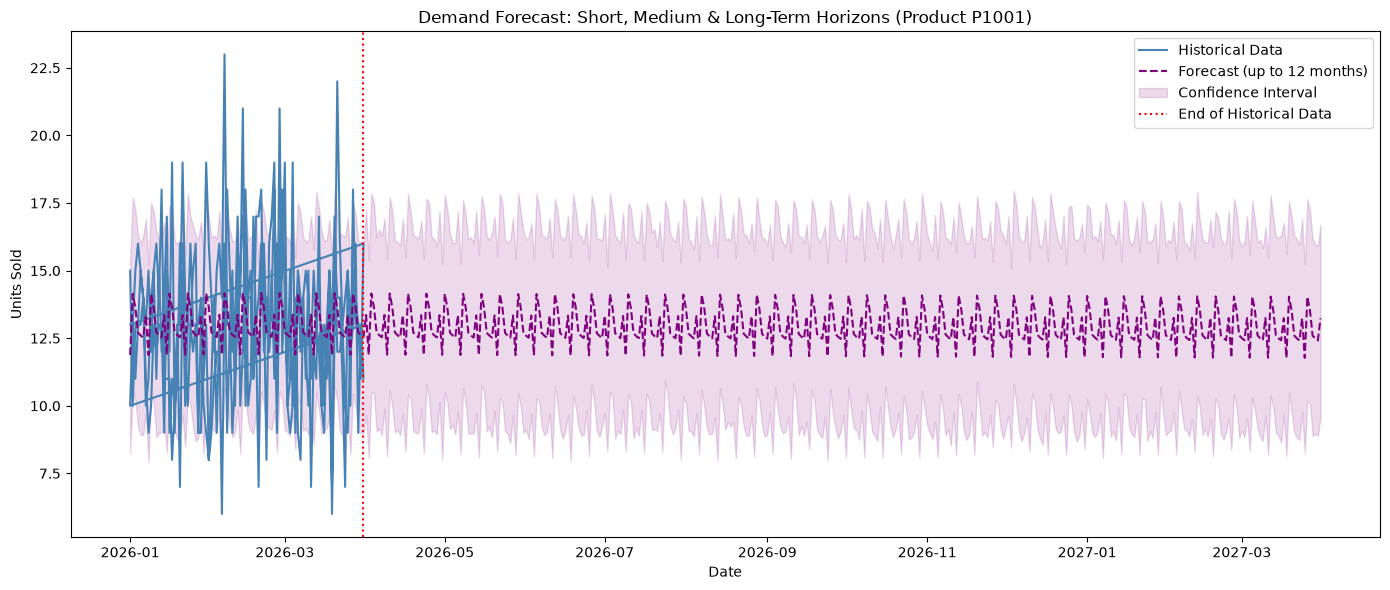

In [44]:
display(Markdown("### 📊 Step 43: Visualizing Forecast Horizons"))

plt.figure(figsize=(14,6))
plt.plot(prophet_full['ds'], prophet_full['y'], label='Historical Data', color='steelblue')
plt.plot(forecast_long['ds'], forecast_long['yhat'], label='Forecast (up to 12 months)', color='purple', linestyle='--')
plt.fill_between(forecast_long['ds'], forecast_long['yhat_lower'], forecast_long['yhat_upper'], color='purple', alpha=0.15, label='Confidence Interval')
plt.axvline(x=prophet_full['ds'].max(), color='red', linestyle=':', label='End of Historical Data')
plt.title('Demand Forecast: Short, Medium & Long-Term Horizons (Product P1001)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
display(Markdown("### 💾 Step 44: Save Extended Forecasting Model"))

import pickle

with open(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\models\prophet_demand_model.pkl", "wb") as f:
    pickle.dump(prophet_model_extended, f)

print("Prophet forecasting model saved successfully!")

### 💾 Step 44: Save Extended Forecasting Model

Prophet forecasting model saved successfully!


In [46]:
display(Markdown("## 🏆 MODEL COMPARISON WITH GRIDSEARCHCV"))
display(Markdown("### 🔬 Step 45: Compare Multiple Models for Demand Forecasting"))

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
import time

# Using our corrected, leak-free demand forecasting dataset (X6, y6)
models_to_test = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1)
}

results = []

for name, model in models_to_test.items():
    start = time.time()
    model.fit(X6_train, y6_train)
    pred = model.predict(X6_test)

    r2 = r2_score(y6_test, pred)
    mae = mean_absolute_error(y6_test, pred)
    rmse = np.sqrt(mean_squared_error(y6_test, pred))
    train_time = time.time() - start

    results.append({
        'Model': name,
        'R² Score': round(r2, 4),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'Training Time (s)': round(train_time, 2)
    })
    print(f"✓ {name} trained")

results_comparison = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_comparison.to_string(index=False))

## 🏆 MODEL COMPARISON WITH GRIDSEARCHCV

### 🔬 Step 45: Compare Multiple Models for Demand Forecasting

✓ Linear Regression trained
✓ Decision Tree trained
✓ Random Forest trained
✓ Gradient Boosting trained
✓ XGBoost trained

MODEL COMPARISON RESULTS
            Model  R² Score  MAE  RMSE  Training Time (s)
    Random Forest    0.7992 2.67  3.72              34.98
          XGBoost    0.7804 2.87  3.89               0.96
    Decision Tree    0.6256 3.54  5.08               3.44
Gradient Boosting    0.2560 5.78  7.17              25.57
Linear Regression    0.0855 6.49  7.95               0.12


In [47]:
display(Markdown("### 🔍 Step 46: Verify Winning Model (Random Forest) — Feature Importance Check"))

best_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
best_rf.fit(X6_train, y6_train)

importance_check = pd.DataFrame({
    'feature': X6.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_check.to_string(index=False))

### 🔍 Step 46: Verify Winning Model (Random Forest) — Feature Importance Check

        feature  importance
     base_price    0.507708
          brand    0.140700
       category    0.084326
inventory_level    0.082535
   discount_pct    0.080677
    day_of_week    0.034072
         region    0.028999
        channel    0.020550
          month    0.014638
         season    0.005795


In [48]:
display(Markdown("### ⚙️ Step 47: GridSearchCV — Hyperparameter Tuning"))

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X6_train, y6_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", round(grid_search.best_score_, 4))

# Evaluate on test set
best_model = grid_search.best_estimator_
final_pred = best_model.predict(X6_test)

final_r2 = r2_score(y6_test, final_pred)
final_mae = mean_absolute_error(y6_test, final_pred)

print(f"\nFinal Test Set Performance:")
print(f"R² Score: {final_r2:.4f}")
print(f"MAE: {final_mae:.2f} units")

### ⚙️ Step 47: GridSearchCV — Hyperparameter Tuning

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
Best CV R² Score: 0.786

Final Test Set Performance:
R² Score: 0.8031
MAE: 2.64 units


In [49]:
display(Markdown("### 💾 Step 48: Save Final Tuned Model"))

joblib.dump(best_model, r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\models\demand_forecast_model_tuned.pkl")

print("Final tuned model saved successfully!")
print(f"Model: Random Forest (tuned via GridSearchCV)")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test R²: {final_r2:.4f} | Test MAE: {final_mae:.2f} units")

### 💾 Step 48: Save Final Tuned Model

Final tuned model saved successfully!
Model: Random Forest (tuned via GridSearchCV)
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
Test R²: 0.8031 | Test MAE: 2.64 units


In [50]:
display(Markdown("## 📊 DOMAIN KNOWLEDGE — KPI EXTRACTION"))
display(Markdown("### 💼 Step 49: Calculate Key Business KPIs"))

# Total Revenue
total_revenue = df['revenue'].sum()

# Revenue by month (for growth calculation)
df['month_year'] = df['date'].dt.to_period('M')
monthly_revenue = df.groupby('month_year')['revenue'].sum().reset_index()
monthly_revenue['month_year'] = monthly_revenue['month_year'].astype(str)

# Revenue Growth % (month over month)
monthly_revenue['growth_pct'] = monthly_revenue['revenue'].pct_change() * 100

# Average Order Value (revenue per unit sold, as proxy)
avg_order_value = df['revenue'].sum() / df['units_sold'].sum()

# Profit Proxy: using discount as a cost indicator (revenue vs base_price*units_sold as "full price" baseline)
df['full_price_revenue'] = df['base_price'] * df['units_sold']
total_full_price_revenue = df['full_price_revenue'].sum()
discount_impact = total_full_price_revenue - total_revenue

print("="*60)
print("KEY BUSINESS KPIs")
print("="*60)
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value: ${avg_order_value:.2f}")
print(f"Total Units Sold: {df['units_sold'].sum():,}")
print(f"Revenue Lost to Discounting: ${discount_impact:,.2f}")
print(f"\nMonthly Revenue & Growth:")
print(monthly_revenue.to_string(index=False))

## 📊 DOMAIN KNOWLEDGE — KPI EXTRACTION

### 💼 Step 49: Calculate Key Business KPIs

KEY BUSINESS KPIs
Total Revenue: $476,460,700.92
Average Order Value: $195.27
Total Units Sold: 2,440,063
Revenue Lost to Discounting: $70,307,476.99

Monthly Revenue & Growth:
month_year      revenue  growth_pct
   2026-01 168201326.93         NaN
   2026-02 151905350.37   -9.688376
   2026-03 156354023.62    2.928582


In [51]:
display(Markdown("### 📈 Step 50: Category & Regional Performance"))

# Revenue by category
category_performance = df.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    units_sold=('units_sold', 'sum'),
    avg_price=('current_price', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

# Revenue by region
region_performance = df.groupby('region').agg(
    total_revenue=('revenue', 'sum'),
    units_sold=('units_sold', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)

print("Category Performance:")
print(category_performance.round(2).to_string(index=False))

print("\nRegional Performance:")
print(region_performance.round(2).to_string(index=False))

### 📈 Step 50: Category & Regional Performance

Category Performance:
   category  total_revenue  units_sold  avg_price
    Apparel    67270545.61      322684     211.76
      Shoes    65413794.53      341640     193.56
Accessories    59117972.52      300905     196.74
Electronics    58709505.84      310884     199.48
     Beauty    58375568.29      292558     196.14
  Groceries    58052895.20      303616     189.43
       Home    58024791.27      273188     214.64
     Sports    51495627.66      294588     180.88

Regional Performance:
region  total_revenue  units_sold
    IN    83725246.40      438595
    UK    81547968.21      399724
    US    79229386.40      402570
    DE    79169124.46      420737
    AU    78665805.58      397080
    CA    74123169.87      381357
